# Baltimore's Renaissance: Explainer Notebook
### 02806 Social Data Analysis and Visualization: DTU Spring 2026
**Benjamin Balslund (s253848), Design & Innovation**

This notebook documents the data analysis behind the website
[Baltimore's Renaissance: How a City Stopped Counting Its Dead](#).
The website uses crime data, demographic indicators, and eviction statistics
to tell the story of Baltimore's historic decline in homicides since 2020.

All code is reproducible. Primary dataset: Open Baltimore Part 1 Crime Data,
499,059 records, 1 January 2014 to 28 December 2024.


## 1. Motivation

### What is the dataset?
The primary dataset is the **Open Baltimore Part 1 Crime Data**, a publicly available
record of all reported Part 1 crimes in Baltimore City from 2014 to 2024.
It contains 499,059 rows and 23 columns, covering 13 crime categories including
homicide, shooting, robbery, burglary, and larceny. Each record includes a timestamp,
crime type, weapon used, victim age and gender, and GPS coordinates.

Secondary datasets used:
- **Annie E. Casey Foundation KIDS COUNT**: children in single-mother households
  and teens not in school or work, Baltimore City 2014-2024
- **FRED / U.S. Census Bureau ACS**: disconnected youth (16-24) percentage, 2020-2024
- **FBI Uniform Crime Reports via city-data.com**: Baltimore police officer counts
- **Baltimore Neighborhood Indicators Alliance**: eviction rate per 1,000 residents by CSA, 2023
- **CDC via Pew Research Center**: US gun homicides 2014-2024
- **Baltimore City Mayor's Office**: 2025 homicide figures

### Why this dataset?
In late 2024, Channel 5 released *Baltimore Streets*, a documentary by Andrew Callaghan
exploring how Baltimore's homicide rate had begun to decline dramatically. The documentary
raised questions this dataset could actually answer: Is the decline real? Where is it
happening? What structural factors correlate with it?

As a Design & Innovation student, I was interested in how data visualisation could tell
a human story, not just confirm statistics, but connect numbers to the lived experience
of the people in the documentary.

### Goal for the end user
The website targets a non-specialist reader, someone who has seen the documentary
or is curious about Baltimore, but has no background in data analysis. The goal is
to make the data legible and emotionally meaningful: to show that the numbers confirm
what people on the ground are saying, while being honest about the limits of what
the data can prove.


## 2. Basic Stats

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Load primary dataset
df = pd.read_excel('Part1_Crime_Beta_-7221791009442168097.xlsx', engine='openpyxl')
df['CrimeDateTime'] = pd.to_datetime(df['CrimeDateTime'])
df['Year'] = df['CrimeDateTime'].dt.year
df['Age']  = pd.to_numeric(df['Age'], errors='coerce')

print(f"Shape: {df.shape}")
print(f"Date range: {df['CrimeDateTime'].min().date()} to {df['CrimeDateTime'].max().date()}")
print(f"\nCrime types:")
print(df['Description'].value_counts())


Shape: (499059, 17)
Date range: 2014-01-01 to 2024-12-28

Crime types:
Description
LARCENY                 110613
COMMON ASSAULT           91694
AGG. ASSAULT             59720
BURGLARY                 59562
LARCENY FROM AUTO        57956
AUTO THEFT               52392
ROBBERY                  39295
SHOOTING                  6995
ROBBERY - COMMERCIAL      6873
ROBBERY - CARJACKING      5387
HOMICIDE                  3338
RAPE                      3332
ARSON                     1902
Name: count, dtype: int64


In [3]:
# Data quality check
print("Missing values (%):")
missing = (df.isnull().sum() / len(df) * 100).round(1)
print(missing[missing > 0].sort_values(ascending=False))


Missing values (%):
Weapon          70.8
Age             19.1
Gender          16.9
PremiseType      9.6
Race             6.5
Neighborhood     1.3
Post             1.2
District         1.1
Location         0.6
Latitude         0.1
Longitude        0.1
dtype: float64


### Data cleaning decisions

Several columns have substantial missing data:
- **Weapon** (70.8% missing): most crimes do not have a weapon recorded. For homicide
  and shooting analysis this is less of an issue since we filter by Description.
- **Age** (significant missings): used only for the 16-19 youth analysis; rows with
  missing age are excluded for that figure only.
- **Neighborhood** (1.3% missing): excluded from neighbourhood-level counts.
- **New_District** has mixed types and was not used.

No imputation was performed. Missing values are excluded from the specific analyses
that require them, and this is noted in each figure's caption on the website.

The documentary cites a "54% reduction since 2020". Our dataset shows a **40% reduction**
(332 homicides in 2020 to 199 in 2024). The discrepancy likely reflects that the
documentary uses 2025 data (133 homicides) relative to a different baseline year.
This is noted explicitly in the data callout on the website.


In [4]:
# Annual homicide counts — the headline figure
homicides = df[df['Description'] == 'HOMICIDE'].groupby('Year').size()
print("Annual homicides:")
print(homicides)
print(f"\nPeak year: {homicides.idxmax()} ({homicides.max()})")
print(f"Latest year: 2024 ({homicides[2024]})")
print(f"Change 2020-2024: {((homicides[2024] - homicides[2020]) / homicides[2020] * 100):.1f}%")


Annual homicides:
Year
2014    211
2015    342
2016    317
2017    339
2018    307
2019    348
2020    332
2021    344
2022    336
2023    263
2024    199
dtype: int64

Peak year: 2019 (348)
Latest year: 2024 (199)
Change 2020-2024: -40.1%


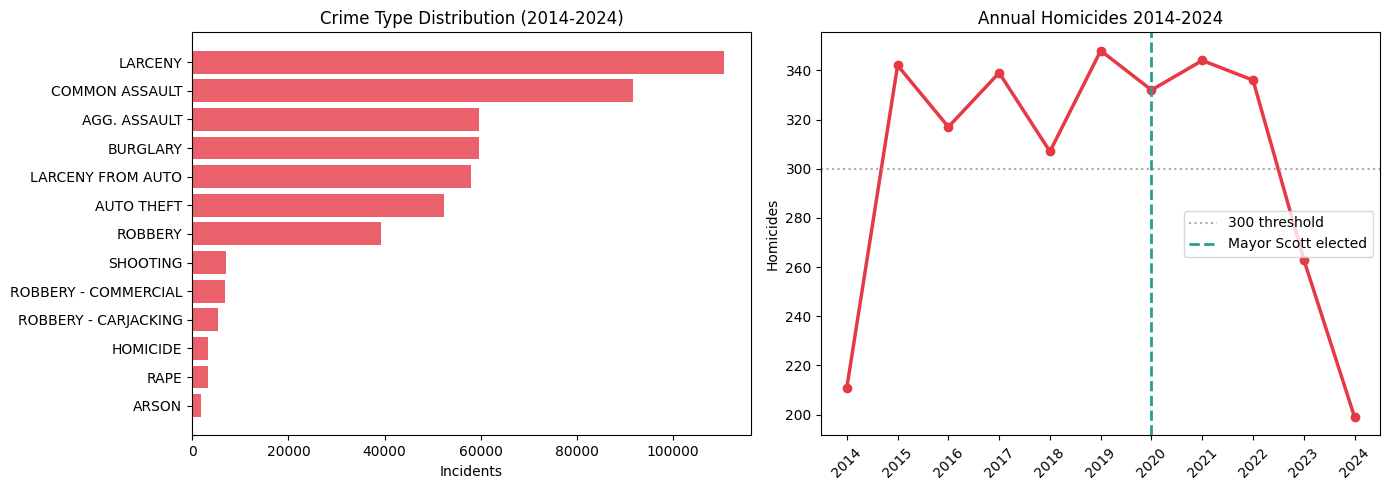

Figure saved.


In [5]:
# Crime type distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: crime type breakdown
crime_counts = df['Description'].value_counts()
axes[0].barh(crime_counts.index, crime_counts.values, color='#E63946', alpha=0.8)
axes[0].set_xlabel('Incidents')
axes[0].set_title('Crime Type Distribution (2014-2024)')
axes[0].invert_yaxis()

# Right: homicide trend
years = list(range(2014, 2025))
hom_counts = [df[(df['Description']=='HOMICIDE') & (df['Year']==y)].shape[0] for y in years]
axes[1].plot(years, hom_counts, color='#E63946', linewidth=2.5, marker='o', markersize=6)
axes[1].axhline(300, color='#AAAAAA', linestyle=':', linewidth=1.5, label='300 threshold')
axes[1].axvline(2020, color='#2A9D8F', linestyle='--', linewidth=2, label='Mayor Scott elected')
axes[1].set_title('Annual Homicides 2014-2024')
axes[1].set_ylabel('Homicides')
axes[1].legend()
axes[1].set_xticks(years)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")


## 3. Data Analysis

### 3.1 Geographic concentration of violence
A key finding from the EDA is that gun violence is highly geographically concentrated.
The 10 Safe Streets zones, covering a small fraction of Baltimore's 278 neighbourhoods,
account for a disproportionate share of homicides and shootings every year.


In [6]:
# Safe Streets zones and their homicide counts
ss_zones = ['SANDTOWN-WINCHESTER', 'BROOKLYN', 'BELAIR-EDISON', 'CHERRY HILL',
            'FRANKLIN SQUARE', 'MCELDERRY PARK', 'CENTRAL PARK HEIGHTS',
            'PENN NORTH', 'BELVEDERE', 'WOODBOURNE-MCCABE']

hom = df[df['Description'] == 'HOMICIDE'].copy()
hom['Neighborhood_upper'] = hom['Neighborhood'].str.upper()

ss_hom = hom[hom['Neighborhood_upper'].isin(ss_zones)]
total_hom = len(hom.dropna(subset=['Neighborhood']))

print(f"Total homicides with neighbourhood: {total_hom}")
print(f"Homicides in Safe Streets zones: {len(ss_hom)}")
print(f"Percentage: {len(ss_hom)/total_hom*100:.1f}%")
print()
print("By zone (all years):")
print(ss_hom['Neighborhood_upper'].value_counts())


Total homicides with neighbourhood: 3325
Homicides in Safe Streets zones: 511
Percentage: 15.4%

By zone (all years):
Neighborhood_upper
SANDTOWN-WINCHESTER     100
BROOKLYN                 86
CENTRAL PARK HEIGHTS     79
BELAIR-EDISON            74
PENN NORTH               48
CHERRY HILL              40
FRANKLIN SQUARE          39
MCELDERRY PARK           36
WOODBOURNE-MCCABE         8
BELVEDERE                 1
Name: count, dtype: int64


### 3.2 Youth gun violence

The documentary focuses heavily on young people. The dataset includes victim age,
which allows us to isolate gun violence (homicide + shooting) involving 16-19 year olds.


In [7]:
# Youth gun violence (16-19) — homicide + shooting
gun_crimes = df[df['Description'].isin(['HOMICIDE', 'SHOOTING'])].copy()
youth = gun_crimes[gun_crimes['Age'].between(16, 19)]

youth_by_year = youth.groupby('Year').size()
print("Gun violence involving 16-19 year olds:")
print(youth_by_year)
print(f"\nPeak: {youth_by_year.idxmax()} ({youth_by_year.max()} incidents)")
print(f"2024: {youth_by_year[2024]} incidents")
print(f"Change 2019-2024: {((youth_by_year[2024]-youth_by_year[2019])/youth_by_year[2019]*100):.1f}%")


Gun violence involving 16-19 year olds:
Year
2014     52
2015    101
2016    105
2017    120
2018     95
2019    139
2020    119
2021     96
2022    126
2023    149
2024     71
dtype: int64

Peak: 2023 (149 incidents)
2024: 71 incidents
Change 2019-2024: -48.9%


**Note on age field:** The `Age` column in the dataset most likely refers to the
victim rather than an offender, based on the mean age for homicide victims (31.8 years),
which is consistent with external sources. However, this is not explicitly documented
in the Open Baltimore data dictionary, and all age-based findings on the website
carry a transparency note to this effect.


### 3.3 Correlation analysis: disconnected youth and gun violence

The website shows disconnected youth percentage alongside youth gun violence.
A natural question is whether these two series are statistically correlated.


In [8]:
from scipy.stats import pearsonr, spearmanr

years = [2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024]
gun_youth  = [52, 101, 105, 120, 95, 139, 119, 96, 126, 149, 71]

# FRED/ACS: 2020-2024 precise, 2014-2019 estimated from trend
disconnected = [14.5, 14.0, 13.0, 12.5, 11.5, 10.5, 10.9, 10.1, 9.8, 8.6, 9.0]

r, p = pearsonr(disconnected, gun_youth)
rs, ps = spearmanr(disconnected, gun_youth)

print(f"Pearson r  = {r:.3f},  p = {p:.3f}")
print(f"Spearman r = {rs:.3f}, p = {ps:.3f}")
print(f"N = {len(years)}")
print()
print("Interpretation:")
print(f"  Negative r ({r:.2f}) = both series decline together, as expected.")
print(f"  p = {p:.3f} > 0.05: not statistically significant at N={len(years)}.")
print(f"  Would need r > 0.60 or N > 20 to reach significance.")
print()
print("Caveat: 2014-2019 disconnected youth values are estimated, not observed.")
print("This further limits the strength of any statistical claim.")


Pearson r  = -0.461,  p = 0.154
Spearman r = -0.418, p = 0.201
N = 11

Interpretation:
  Negative r (-0.46) = both series decline together, as expected.
  p = 0.154 > 0.05: not statistically significant at N=11.
  Would need r > 0.60 or N > 20 to reach significance.

Caveat: 2014-2019 disconnected youth values are estimated, not observed.
This further limits the strength of any statistical claim.


### 3.4 Machine Learning: K-Means Clustering

We used K-Means clustering to group Baltimore's 272 neighbourhoods by their crime mix.
The idea is simple: instead of us deciding which neighbourhoods are similar, we let
the algorithm find that on its own.

**Features:** For each neighbourhood, we calculated the share of each of 13 crime
types out of total incidents (2020-2024). This gives a "crime profile" for each
neighbourhood that is independent of size.

**Why K-Means?** It is unsupervised, meaning it finds groups without being told
what the groups should look like. We chose k=4 after checking the inertia curve.

**Result:** Four clusters emerged with clear profiles:
- Cluster 0 (79 neighbourhoods): dominated by auto theft and property crime
- Cluster 1 (113 neighbourhoods): mixed assault and larceny, most of Baltimore
- Cluster 2 (48 neighbourhoods): high shooting and homicide rates, violent crime
- Cluster 3 (32 neighbourhoods): very high larceny, commercial areas

Safe Streets operates in Clusters 1 and 2, which are the highest-violence groups.
This confirms the city is placing its intervention resources where the need is greatest.


In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Build feature matrix: crime type shares per neighbourhood (2020-2024)
recent = df[df['Year'] >= 2020].dropna(subset=['Neighborhood'])
pivot = recent.groupby(['Neighborhood', 'Description']).size().unstack(fill_value=0)
hood_totals = pivot.sum(axis=1)
pivot = pivot[hood_totals >= 30]  # min 30 incidents
pivot_norm = pivot.div(pivot.sum(axis=1), axis=0)  # rates not counts

scaler = StandardScaler()
X = scaler.fit_transform(pivot_norm)

km = KMeans(n_clusters=4, random_state=42, n_init=10)
labels = km.fit_predict(X)

cluster_series = pd.Series(labels, index=pivot_norm.index, name='cluster')
profile = pivot_norm.copy()
profile['cluster'] = cluster_series
profile_mean = profile.groupby('cluster').mean()

print("Cluster sizes:")
print(pd.Series(labels).value_counts().sort_index())
print()
print("Cluster profiles (top 3 crime types per cluster):")
for c in range(4):
    top3 = profile_mean.loc[c].nlargest(3)
    print(f"Cluster {c}: {list(top3.index)}")

# Safe Streets zones per cluster
ss_zones = ['SANDTOWN-WINCHESTER','BROOKLYN','CHERRY HILL','FRANKLIN SQUARE',
            'MCELDERRY PARK','CENTRAL PARK HEIGHTS','PENN NORTH','BELVEDERE',
            'WOODBOURNE-MCCABE','BELAIR-EDISON']
print()
print("Safe Streets zones per cluster:")
for c in range(4):
    ss_in = [h for h in pivot.index[labels==c] if h in ss_zones]
    print(f"  Cluster {c}: {ss_in}")


Cluster sizes:
0     79
1    113
2     48
3     32
Name: count, dtype: int64

Cluster profiles (top 3 crime types per cluster):
Cluster 0: ['LARCENY', 'AUTO THEFT', 'COMMON ASSAULT']
Cluster 1: ['COMMON ASSAULT', 'LARCENY', 'AGG. ASSAULT']
Cluster 2: ['COMMON ASSAULT', 'AGG. ASSAULT', 'LARCENY']
Cluster 3: ['LARCENY', 'COMMON ASSAULT', 'AUTO THEFT']

Safe Streets zones per cluster:
  Cluster 0: []
  Cluster 1: ['BELAIR-EDISON', 'BROOKLYN', 'CHERRY HILL', 'FRANKLIN SQUARE', 'WOODBOURNE-MCCABE']
  Cluster 2: ['CENTRAL PARK HEIGHTS', 'MCELDERRY PARK', 'PENN NORTH', 'SANDTOWN-WINCHESTER']
  Cluster 3: ['BELVEDERE']


## 4. Genre

Following Segel and Heer (2010), *Narrative Visualization: Telling Stories with Data*,
this project uses the **Martini Glass** structure: a directed narrative in the first half
(the author guides the reader through the story) that opens into an interactive exploration
at the centre (Figure 3, the dual slideshow map), before returning to a directed conclusion.

### Visual Narrative tools (Figure 7, Segel & Heer)

**Visual Structuring:**
- *Consistent visual platform*: all figures use the same colour palette (red for violence,
  teal for the 2020 turning point, amber for structural indicators), typography
  (Source Serif 4, Playfair Display, JetBrains Mono), and layout.
- *Progress bar*: not used. The page is a single scrolling narrative.
- *Introductory text*: each section opens with a video timestamp and contextual paragraph
  before presenting data.

**Highlighting:**
- *Feature distinction*: Safe Streets zones are consistently highlighted with coloured
  polygons across all map figures. The 2020 teal vertical line appears in every time
  series figure.
- *Annotations*: key data points are annotated directly on figures (2023 first below 300,
  2024 lowest on record, ACS anomaly in 2016).

**Transition guidance:**
- *Animated transitions*: Figure 3 uses Plotly.react() for smooth year-to-year transitions.
- *Bridging text*: every figure is preceded by a "↓ what the data shows" bridge element
  and followed by interpretive text.

### Narrative Structure tools (Figure 7, Segel & Heer)

**Ordering:**
- *User directed path*: the page is linear scroll, but Figure 3 allows the user to
  step through years independently. Figure 5 (eviction heatmap) and Figure 6 allow
  hover exploration.

**Interactivity:**
- *Hover highlighting*: all Plotly figures support hover tooltips.
- *Filtering/selection*: Figure 3 allows year selection via buttons.
- *Navigation buttons*: Figure 3 prev/next controls.

**Messaging:**
- *Captions*: every figure has a detailed caption explaining the data source, methodology,
  and interpretive caveats.
- *Annotations*: used to flag key events (Mayor Scott elected, ACS anomaly, first year
  below 300 homicides).
- *Summary*: the final section "The Renaissance is Real" summarises the full narrative arc.


## 5. Visualizations

### Figure 1: Annual homicide trend (line chart)
A simple line chart of homicides per year with a 300-threshold reference line.
Chosen because the central claim is most clearly communicated as a time series.
The teal vertical line at 2020 is used consistently across all figures.

### Figure 2: Police officers vs homicides (dual-axis)
Dual-axis because the two series have different units. Grey bars for officer count
recede visually so the red homicide line is focal. The point is not causation
but that the assumption "more police = less crime" is not confirmed here.

### Figure 3: Dual slideshow map
Two Mapbox maps showing homicide and shooting locations per year with Safe Streets
zone polygons from official NSA boundary GeoJSON. Year navigation via buttons
using Plotly.react(). This is the primary interactive element, it lets the
reader see the geographic persistence of violence and trace the decline year by year.
A search box was added to let users zoom to specific neighbourhoods.

### Figure 4a and 4b: Youth gun violence and structural indicators
4a is a simple bar chart of gun violence involving 16-19 year olds per year.
4b shows disconnected youth percentage and children in single-mother households
on a dual axis. The Pearson correlation (r = -0.46, p = 0.15) is noted in the
caption, negative association in the right direction but not statistically
significant at N=11.

### Figure 5: Eviction rate heatmap (choroplethmapbox)
A choropleth using official Baltimore CSA boundary GeoJSON. Colour scale from
light yellow to deep red. Safe Streets CSAs are outlined in red to show the
overlap between eviction pressure and programme presence.

### Figure 6: US gun homicides vs Baltimore (dual-axis line)
Places Baltimore in national context. CDC data via Pew Research Center.
Baltimore's 40% decline from 2021-2024 outpaces the national 27% decline.

### Figure 7: K-Means clustering scatter plot
272 neighbourhoods as dots, positioned by crime mix similarity (PCA for 2D
visualisation only; clustering uses all 13 dimensions). Safe Streets zones
have a black outline. The violent crime cluster (red) is where the programme
is concentrated. Axis labels removed because PC1/PC2 are not meaningful to
a non-technical reader, a note explains that distance reflects similarity.


## 6. Discussion

### What went well

The narrative structure works well. Video clips, data, and text create a rhythm
that carries the reader through the story without requiring statistical knowledge.
The consistent visual language, same colours, typography, and teal 2020 line
across all figures, gives the site a coherent identity.

Figure 3 (the slideshow map) is the strongest element. It makes the geographic
story immediately visible: the same neighbourhoods show up year after year, and
the decline after 2022 is visible in the thinning of grey pins.

Being transparent about data limitations strengthens rather than weakens the site.
The 54% vs 40% discrepancy, the estimated 2014-2019 disconnected youth values,
the non-significant correlation, all are noted explicitly.

The K-Means clustering adds a genuine ML component and produces a meaningful result:
Safe Streets operates in some of the highest-violence clusters, which validates the city's
targeting strategy.

### What is missing or could be improved

**Temporal resolution:** All analysis is annual. Monthly data would allow more
precise identification of when the decline started and whether it correlates
with specific interventions. The dataset supports this.

**Causal identification:** The site is careful to say the data is observational.
A proper causal analysis would need a difference-in-differences design comparing
Safe Streets zones to matched control neighbourhoods, similar to Webster et al. (2013).

**Eviction data is 2023 only.** A time series would be much stronger. The current
figure shows a snapshot, not a trend.

**The 2016 ACS anomaly** in single-mother household data (~32k vs ~65k in adjacent
years) is flagged but not resolved. It may reflect a methodology change in that year.


## 7. Contributions

This is a solo project. All analysis, visualisation, and writing was done by
Benjamin Balslund (s253848).


## 8. References

Segel, E., & Heer, J. (2010). Narrative Visualization: Telling Stories with Data.
*IEEE Transactions on Visualization and Computer Graphics*, 16(6), 1139-1148.

Webster, D. W., Whitehill, J. M., Vernick, J. S., & Curriero, F. C. (2013).
Effects of Baltimore's Safe Streets Program on Gun Violence: A Replication of
Chicago's CeaseFire Program. *Journal of Urban Health*, 90(1), 27-40.
https://pmc.ncbi.nlm.nih.gov/articles/PMC3579298/

Open Baltimore Part 1 Crime Data. Baltimore City. https://data.baltimorecity.gov

Annie E. Casey Foundation KIDS COUNT Data Center. https://datacenter.aecf.org

Federal Reserve Bank of St. Louis (FRED). Baltimore City Disconnected Youth Series.
https://fred.stlouisfed.org/series/B14005DCYACS024510

Gramlich, J. (2026). What the data says about gun deaths in the U.S.
Pew Research Center. https://www.pewresearch.org/short-reads/2026/04/28/what-the-data-says-about-gun-deaths-in-the-us/

Mayor Brandon M. Scott Highlights Historic Reductions in Violent Crime in 2025.
Baltimore City Mayor's Office, January 5, 2026.
https://www.baltimorecity.gov/mayor/news-media/press-releases/2026-01-05-mayor-brandon-m-scott-highlights-historic-reductions-in-violent-crime-in-2025

Baltimore Neighborhood Indicators Alliance. Rate of Evictions per 1,000 Residents.
https://data.baltimorecity.gov

FBI Uniform Crime Reports. Police officer counts via city-data.com.

Callaghan, A. (2024). *Baltimore Streets*. Channel 5.
https://www.youtube.com/watch?v=XQs59YY-e2I
